In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

In [2]:
dataset=pd.read_csv("StudentsPerformance.csv")

In [3]:
dataset.shape

(1000, 8)

In [4]:
dataset.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
dataset = dataset.rename(columns = {
    "race/ethnicity": "race",
    "parental level of education": "parent_edu",
    "test preparation course": "test_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score"
})
dataset # Renaming columns to shorter and consistent names for better readability and ease of use


,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [6]:
dataset["total_score"]=dataset["math_score"]+dataset["reading_score"]+dataset["writing_score"] #Creating a new feature 'total_score' by summing math, reading, and writing scores


In [7]:
dataset.head() #top five records

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [8]:
dataset.isnull().sum() # Checking the number of missing (null) values in each column

gender           0
race             0
parent_edu       0
lunch            0
test_course      0
math_score       0
reading_score    0
writing_score    0
total_score      0
dtype: int64

In [9]:
dataset.loc[len(dataset)]=[
    "male",
    "group A",
    np.nan,
    "standard",
    np.nan,
    78,
    56,
    89,
    223
] # Adding a new row with missing values to demonstrate missing value handling

In [10]:
dataset.isnull().sum()

gender           0
race             0
parent_edu       1
lunch            0
test_course      1
math_score       0
reading_score    0
writing_score    0
total_score      0
dtype: int64

<Axes: ylabel='reading_score'>

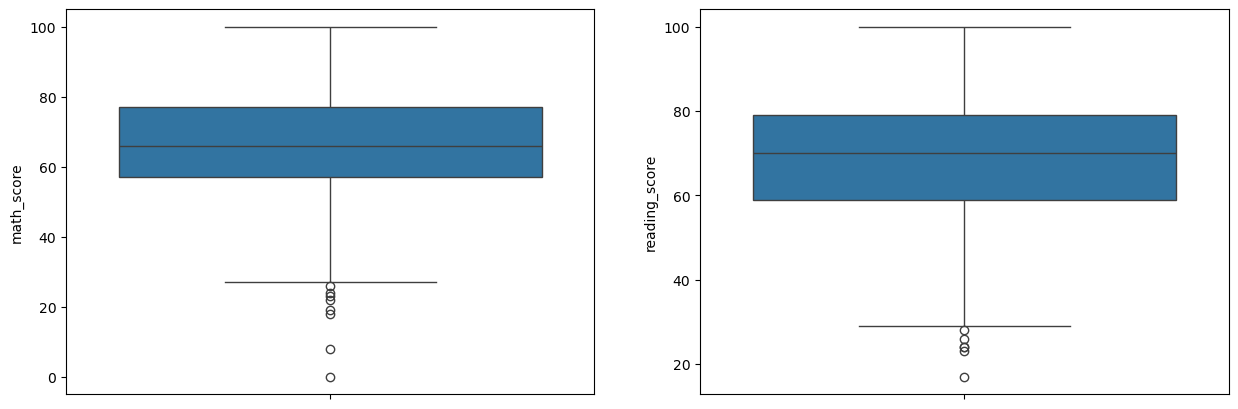

In [29]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.boxplot(data=dataset["math_score"], ax=axes[0])
sns.boxplot(data=dataset["reading_score"], ax=axes[1])  # Visualizing math and reading scores using boxplots to identify outliers

In [12]:
dataset["math_zscore"]=stats.zscore(dataset["math_score"]) #Calculates the Z-score for every value in the math_score column.
#z=x-mean/std

In [15]:
dataset["math_outlier"] = np.where(
    np.abs(dataset["math_zscore"]) > 3,
    "outlier",
    None
)


In [16]:
dataset.head()

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score,total_score,math_zscore,math_outlier
0,female,group B,bachelor's degree,standard,none,72,72,74,218,0.389313,None
1,female,group C,some college,standard,completed,69,90,88,247,0.191327,None
2,female,group B,master's degree,standard,none,90,95,93,278,1.577228,None
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,-1.260569,None
4,male,group C,some college,standard,none,76,78,75,229,0.653294,None


In [17]:
dataset["reading_zscore"]=stats.zscore(dataset["reading_score"])

In [19]:
dataset["reading_outlier"]=np.where(
    np.abs(dataset["reading_zscore"])>3,
    "outlier",
    None
)

In [20]:
dataset.head()

,gender,race,parent_edu,lunch,test_course,math_score,reading_score,writing_score,total_score,math_zscore,math_outlier,reading_zscore,reading_outlier
0,female,group B,bachelor's degree,standard,none,72,72,74,218,0.389313,None,0.194918,None
1,female,group C,some college,standard,completed,69,90,88,247,0.191327,None,1.428511,None
2,female,group B,master's degree,standard,none,90,95,93,278,1.577228,None,1.771175,None
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,-1.260569,None,-0.833075,None
4,male,group C,some college,standard,none,76,78,75,229,0.653294,None,0.606116,None


In [21]:
scaler=MinMaxScaler() #create the instance

In [22]:
dataset["total_score_scaled"]=scaler.fit_transform(dataset[["total_score"]]) #fit calculate min max of the column

In [23]:
dataset[["total_score", "total_score_scaled"]].head()

,total_score,total_score_scaled
0,218,0.699634
1,247,0.805861
2,278,0.919414
3,148,0.443223
4,229,0.739927


In [25]:
# Handling missing categorical values using Mode
dataset["parent_edu"] = dataset["parent_edu"].fillna(dataset["parent_edu"].mode()[0])

In [26]:
dataset["test_course"] = dataset["test_course"].fillna(dataset["test_course"].mode()[0])

In [27]:
dataset.isnull().sum()

gender                  0
race                    0
parent_edu              0
lunch                   0
test_course             0
math_score              0
reading_score           0
writing_score           0
total_score             0
math_zscore             0
math_outlier          997
reading_zscore          0
reading_outlier       997
total_score_scaled      0
dtype: int64